In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Study hrs , Attendance --> Pass or Fail
import random

X = []
Y = []

for _ in range(1000):
    study_hours = random.randint(0, 20)        # 0–20 hours
    attendance = random.randint(0, 100)        # 0–100 %

    # decision logic
    score = 0.7 * study_hours + 0.3 * (attendance / 5)

    if score >= 15:
        result = "Pass"
    else:
        result = "fail"

    X.append([study_hours, attendance])
    Y.append(result)


<Axes: xlabel='features1', ylabel='features2'>

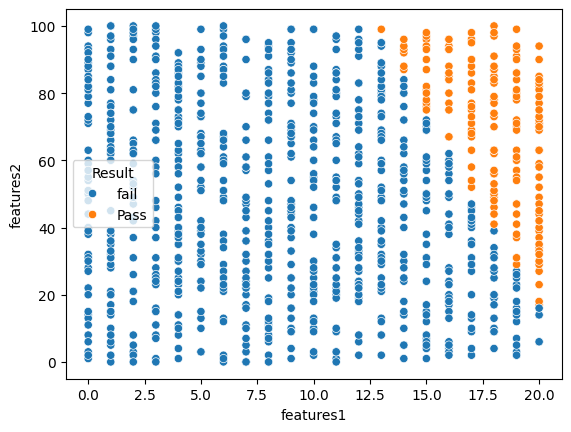

In [49]:
df = pd.DataFrame(X , columns = ["features1" , "features2"])
df["Result"] = Y

sns.scatterplot(
    data = df , 
    x = "features1",
    y = "features2",
    hue = "Result"
)

In [16]:
from sklearn.metrics import precision_score , accuracy_score , recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [17]:
heart_df = pd.read_csv("heart.csv" )

X = heart_df.drop("target"  , axis = 1)
Y = heart_df["target"]

In [20]:
x_train , x_test , y_train , y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [36]:
kNN_model = KNeighborsClassifier(n_neighbors = 5)
kNN_model.fit(x_train_scaled , y_train)

KNeighborsClassifier()

In [37]:
y_pred = kNN_model.predict(x_test_scaled)

In [38]:
# Evaluation

print(f"recall score : {recall_score(y_test , y_pred)}")
print(f"accuracy score : {accuracy_score(y_test , y_pred)}")
print(f"precision score : {precision_score(y_test , y_pred)}")

recall score : 0.90625
accuracy score : 0.9016393442622951
precision score : 0.90625


In [46]:
# Cross Validation for hyperparameter tuning using GridSearch
from sklearn.model_selection import GridSearchCV

classifier = KNeighborsClassifier()
param_grid = {"n_neighbors" : [3 ,5, 7, 9]}

classifierCV = GridSearchCV(
    classifier,
    param_grid,
    cv=5,
    scoring = "recall"
)

classifierCV.fit(x_train_scaled , y_train)

y_pred = classifierCV.predict(x_test_scaled)

print(f"recall score : {recall_score(y_test , y_pred)}")
print(f"accuracy score : {accuracy_score(y_test , y_pred)}")
print(f"precision score : {precision_score(y_test , y_pred)}")

# Result
res = pd.DataFrame(classifierCV.cv_results_)
print(res[["param_n_neighbors", "mean_test_score"]] , classifierCV.best_params_)

recall score : 0.90625
accuracy score : 0.8688524590163934
precision score : 0.8529411764705882
   param_n_neighbors  mean_test_score
0                  3         0.864387
1                  5         0.857550
2                  7         0.871795
3                  9         0.856980 {'n_neighbors': 7}


In [47]:
# Pipeline
from sklearn.pipeline import Pipeline

x_train , x_test , y_train , y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 42
)

pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('knn' , KNeighborsClassifier())
])

param_grid = {"knn__n_neighbors" : [3 ,5, 7, 9]}

classifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring = "recall"
)

classifierCV.fit(x_train , y_train)

y_pred = classifierCV.predict(x_test)

print(f"recall score : {recall_score(y_test , y_pred)}")
print(f"accuracy score : {accuracy_score(y_test , y_pred)}")
print(f"precision score : {precision_score(y_test , y_pred)}")

recall score : 0.90625
accuracy score : 0.9180327868852459
precision score : 0.9354838709677419
